Uma empresa afirma que o tempo médio de atendimento é 10 minutos.
Coletamos uma amostra e queremos testar:

H0: 𝜇 = 10

H1: 𝜇 <> 10

Nível de significância: 𝛼 = 0.05


In [1]:
import numpy as np
from scipy import stats

# Amostra (tempo de atendimento em minutos)
data = np.array([11.2, 9.8, 10.5, 10.9, 11.0, 9.7, 10.3, 10.8, 11.1, 10.4])

# Valor hipotetizado
mu_0 = 10

# One-sample t-test
t_statistic, p_value = stats.ttest_1samp(data, mu_0)

print("Média amostral:", np.mean(data))
print("Estatística t:", t_statistic)
print("Valor-p:", p_value)

Média amostral: 10.569999999999999
Estatística t: 3.4330705494969664
Valor-p: 0.007471886470362086


O teste retorna:

- t_statistic → quantos erros-padrão a média está distante de 10

- p_value → probabilidade de observar um valor tão extremo quanto esse sob 



Regra de decisão:

Se p_value < 0.05 → rejeitamos H0



Se p_value ≥ 0.05 → não rejeitamos 
​


Teste de Shapiro–Wilk (mais recomendado para n pequeno/médio)

In [2]:
import numpy as np
from scipy import stats

data = np.array([11.2, 9.8, 10.5, 10.9, 11.0, 9.7, 10.3, 10.8, 11.1, 10.4])

stat, p_value = stats.shapiro(data)

print("Estatística W:", stat)
print("Valor-p:", p_value)

Estatística W: 0.9210942970394462
Valor-p: 0.3661722883964641


- Se p_value > 0.05 → não rejeitamos normalidade

- Se p_value ≤ 0.05 → evidência contra normalidade

### Pipeline completo incluindo intervalo de confiança

Tamanho da amostra: 10
Média amostral: 10.569999999999999
--------------------------------------------------
Teste de Shapiro-Wilk
Estatística: 0.9210942970394462
p-valor: 0.3661722883964641
--------------------------------------------------
Normalidade NÃO rejeitada → usar t-test

Resultado do t-test:
Estatística t: 3.4330705494969664
p-valor: 0.007471886470362086

Intervalo de Confiança 95% para a média:
(10.1944, 10.9456)
--------------------------------------------------
Rejeitamos H0 ao nível de 5%


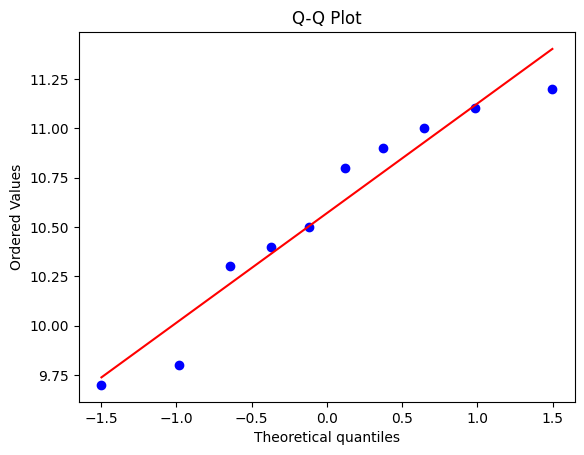

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# -----------------------------
# Configuração
# -----------------------------
alpha = 0.05
confidence = 0.95
mu_0 = 10

data = np.array([11.2, 9.8, 10.5, 10.9, 11.0, 9.7, 10.3, 10.8, 11.1, 10.4])

n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)

print("Tamanho da amostra:", n)
print("Média amostral:", mean)
print("-" * 50)

# -----------------------------
# 1️⃣ Teste de Normalidade
# -----------------------------
shapiro_stat, shapiro_p = stats.shapiro(data)

print("Teste de Shapiro-Wilk")
print("Estatística:", shapiro_stat)
print("p-valor:", shapiro_p)
print("-" * 50)

# -----------------------------
# 2️⃣ Escolha do teste
# -----------------------------
if shapiro_p > alpha:
    
    print("Normalidade NÃO rejeitada → usar t-test")
    
    # t-test
    t_stat, p_value = stats.ttest_1samp(data, mu_0)
    
    # Intervalo de confiança
    df = n - 1
    t_crit = stats.t.ppf((1 + confidence) / 2, df)
    margin_error = t_crit * std / np.sqrt(n)
    
    ci_lower = mean - margin_error
    ci_upper = mean + margin_error
    
    print("\nResultado do t-test:")
    print("Estatística t:", t_stat)
    print("p-valor:", p_value)
    
    print(f"\nIntervalo de Confiança {int(confidence*100)}% para a média:")
    print(f"({ci_lower:.4f}, {ci_upper:.4f})")

else:
    
    print("Normalidade rejeitada → usar Wilcoxon")
    
    w_stat, p_value = stats.wilcoxon(data - mu_0)
    
    print("\nResultado do Wilcoxon:")
    print("Estatística W:", w_stat)
    print("p-valor:", p_value)
    
    print("\nIntervalo de confiança paramétrico não é apropriado.")
    print("Pode-se usar bootstrap para IC não paramétrico.")

print("-" * 50)

# -----------------------------
# 3️⃣ Decisão final
# -----------------------------
if p_value < alpha:
    print("Rejeitamos H0 ao nível de 5%")
else:
    print("Não rejeitamos H0 ao nível de 5%")

# -----------------------------
# 4️⃣ Q-Q Plot
# -----------------------------
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

O Q-Q plot (Quantile–Quantile Plot) é um gráfico diagnóstico usado para comparar a distribuição empírica dos dados com uma distribuição teórica (geralmente a normal).

Ele responde à pergunta:

Os meus dados seguem aproximadamente uma distribuição normal?

Como ele funciona

O gráfico compara:

Quantis teóricos da distribuição de referência (ex: normal)

Quantis observados da amostra

Cada ponto do gráfico representa:

        (quantil teórico, quantil amostral)

Se os dados seguem a distribuição teórica, os pontos ficam aproximadamente sobre uma linha reta.

## Pipeline para t-test

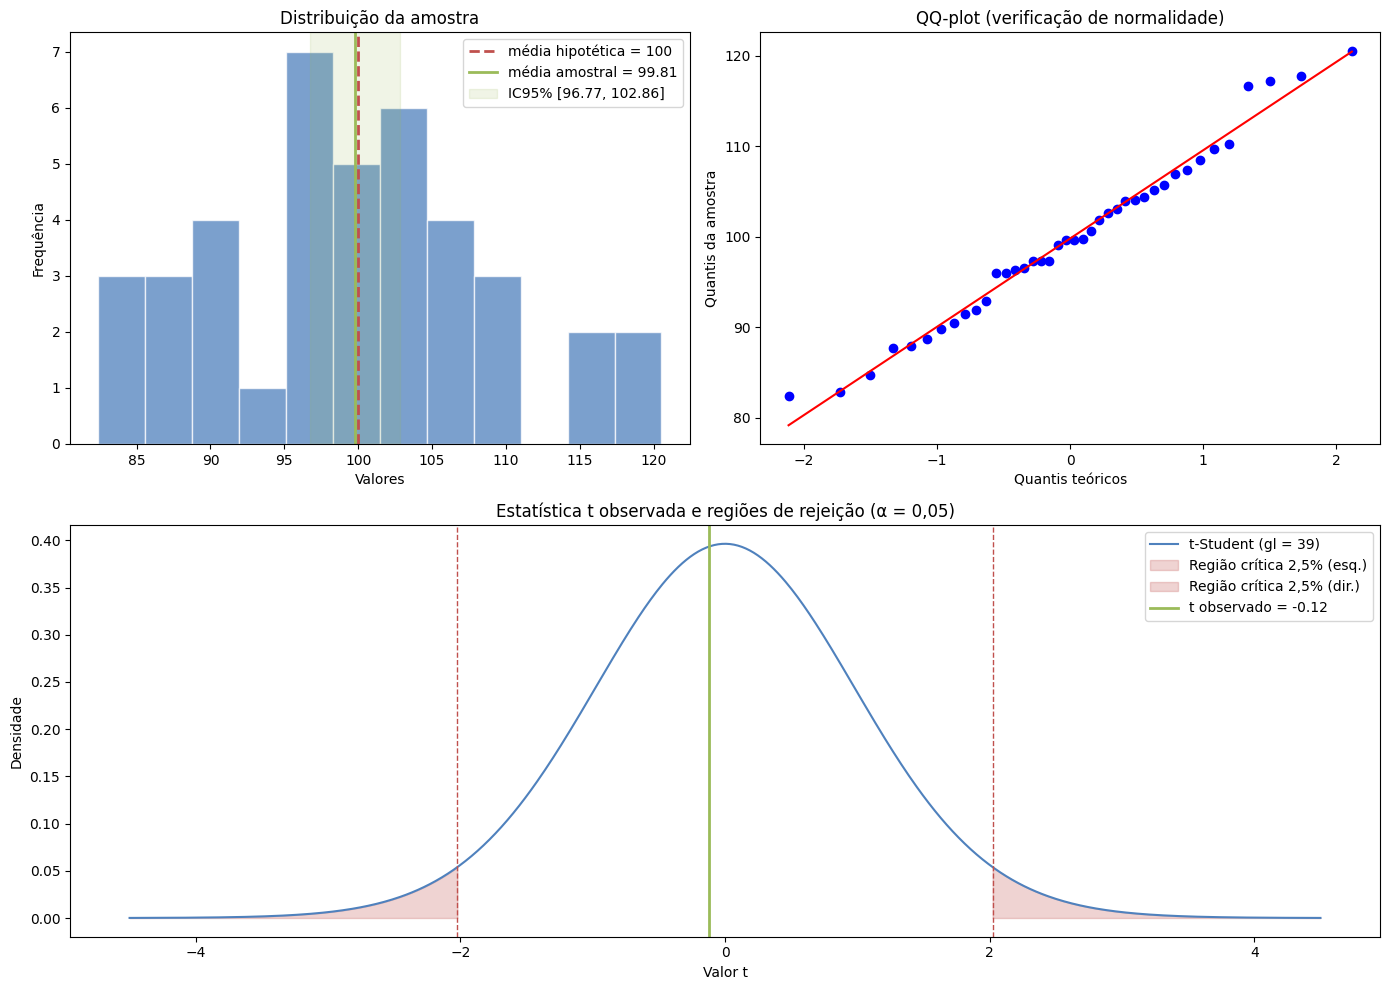

{'n': 40, 'media_amostral': np.float64(99.81363161582061), 'desvio_padrao_amostral': np.float64(9.528089812659248), 'sem': np.float64(1.5065232779325128), 't_observado': np.float64(-0.12370760340003008), 'p_valor': np.float64(0.9021821686868052), 'gl': 39, 'IC95%': (np.float64(96.7664006607225), np.float64(102.86086257091873))}


In [4]:
from scipy.stats import ttest_1samp
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# --- Substitua 'amostra' pelos seus dados ---
# Ex.: amostra = np.array([5.1, 6.3, 5.9, 7.0, 6.1, ...])
np.random.seed(42)
amostra = np.random.normal(loc=102, scale=10, size=40)

popmean = 100
alpha = 0.05

# Teste t de uma amostra
res = ttest_1samp(amostra, popmean=popmean, alternative='two-sided')
t_stat, p_val = res.statistic, res.pvalue
n = amostra.size
gl = n - 1

# Estatísticas descritivas e IC95%
media = amostra.mean()
sem = stats.sem(amostra)
crit = stats.t.ppf(1 - alpha/2, df=gl)
ci_low = media - crit * sem
ci_high = media + crit * sem

# ---------- Gráficos ----------
plt.figure(figsize=(14, 10))

# 1) Histograma com média amostral, média hipotética e IC
ax1 = plt.subplot(2, 2, 1)
ax1.hist(amostra, bins=12, color='#4F81BD', alpha=0.75, edgecolor='white')
ax1.axvline(popmean, color='#C0504D', linestyle='--', linewidth=2, label=f"média hipotética = {popmean}")
ax1.axvline(media,   color='#9BBB59', linestyle='-',  linewidth=2, label=f"média amostral = {media:.2f}")
ax1.axvspan(ci_low, ci_high, color='#9BBB59', alpha=0.15, label=f"IC95% [{ci_low:.2f}, {ci_high:.2f}]")
ax1.set_title('Distribuição da amostra')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Frequência')
ax1.legend()

# 2) QQ-plot (normalidade)
ax2 = plt.subplot(2, 2, 2)
stats.probplot(amostra, dist="norm", plot=ax2)
ax2.set_title('QQ-plot (verificação de normalidade)')
ax2.set_xlabel('Quantis teóricos')
ax2.set_ylabel('Quantis da amostra')

# 3) Distribuição t com regiões críticas e t observado
ax3 = plt.subplot(2, 1, 2)
xs = np.linspace(-4.5, 4.5, 600)
ax3.plot(xs, stats.t.pdf(xs, df=gl), color='#4F81BD', label=f"t-Student (gl = {gl})")
crit_right = stats.t.ppf(1 - alpha/2, df=gl)
crit_left  = -crit_right
x_fill_left  = np.linspace(xs.min(), crit_left, 200)
x_fill_right = np.linspace(crit_right, xs.max(), 200)
ax3.fill_between(x_fill_left,  stats.t.pdf(x_fill_left,  df=gl), color='#C0504D', alpha=0.25, label='Região crítica 2,5% (esq.)')
ax3.fill_between(x_fill_right, stats.t.pdf(x_fill_right, df=gl), color='#C0504D', alpha=0.25, label='Região crítica 2,5% (dir.)')
ax3.axvline(t_stat, color='#9BBB59', linestyle='-', linewidth=2, label=f"t observado = {t_stat:.2f}")
ax3.axvline(crit_left,  color='#C0504D', linestyle='--', linewidth=1)
ax3.axvline(crit_right, color='#C0504D', linestyle='--', linewidth=1)
ax3.set_title('Estatística t observada e regiões de rejeição (α = 0,05)')
ax3.set_xlabel('Valor t')
ax3.set_ylabel('Densidade')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

print({
    'n': n,
    'media_amostral': media,
    'desvio_padrao_amostral': np.std(amostra, ddof=1),
    'sem': sem,
    't_observado': t_stat,
    'p_valor': p_val,
    'gl': gl,
    'IC95%': (ci_low, ci_high),
})

### Pipeline para Z-test

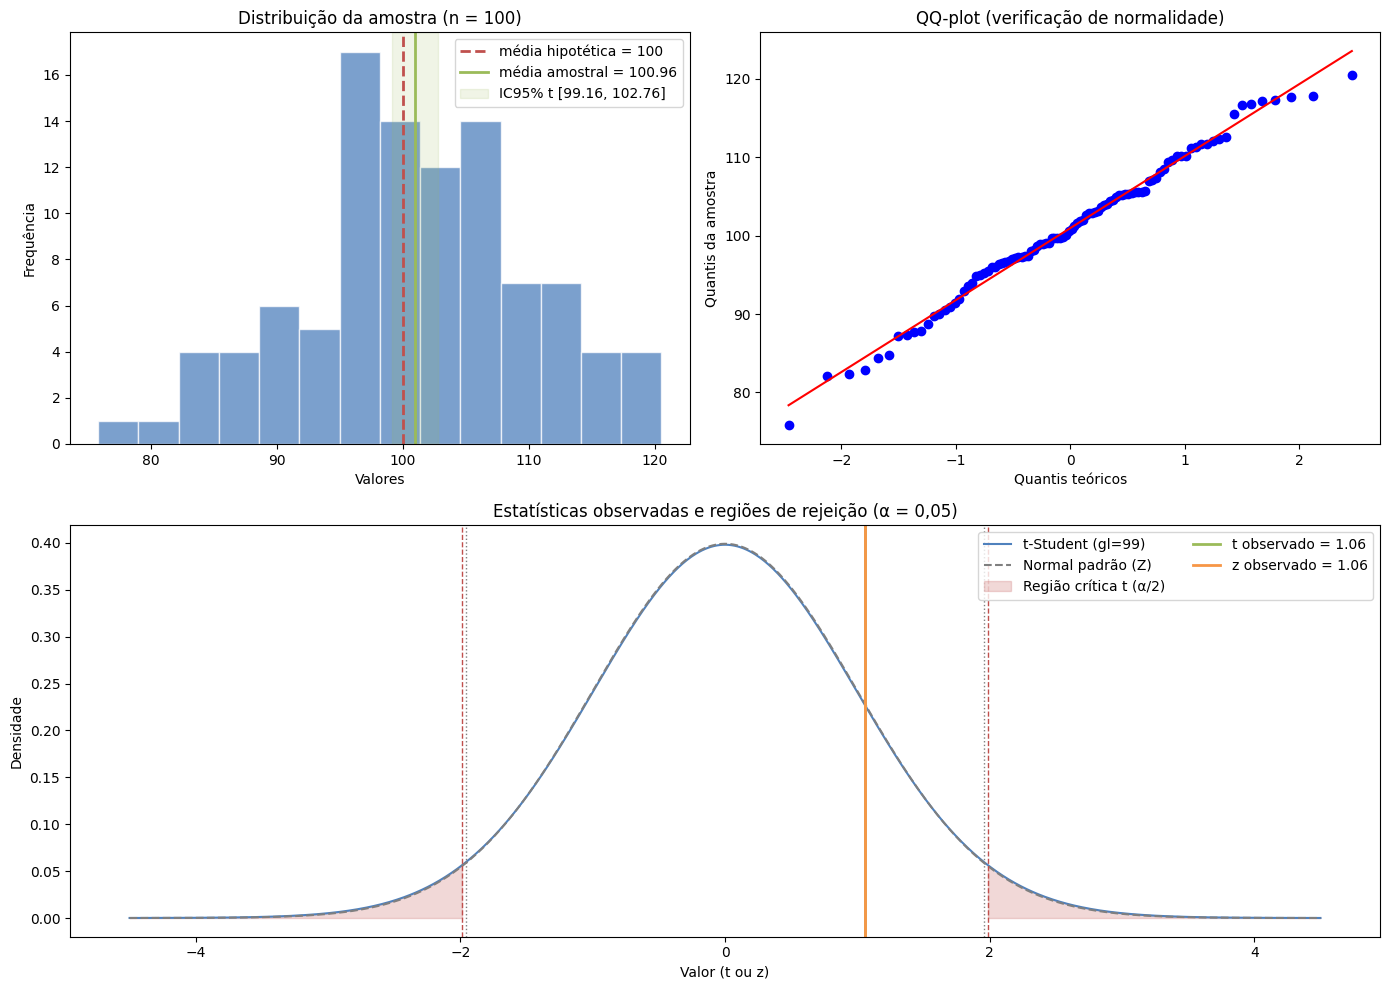

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -------- Parâmetros do experimento --------
np.random.seed(42)
n = 100
popmean = 100
alpha = 0.05

# Gerar amostra (exemplo didático): média ligeiramente > popmean
amostra = np.random.normal(loc=102, scale=10, size=n)

# -------- Testes de hipótese --------
# t-teste de uma amostra (bilateral)
res_t = stats.ttest_1samp(amostra, popmean=popmean, alternative='two-sided')

t_stat = float(res_t.statistic)
p_val_t = float(res_t.pvalue)

# Z-test (aproximação para n grande)
media = float(np.mean(amostra))
std_amostral = float(np.std(amostra, ddof=1))
sem = std_amostral / np.sqrt(n)
from math import sqrt
from scipy.stats import norm
z_stat = (media - popmean) / (std_amostral / np.sqrt(n))
p_val_z = 2 * (1 - norm.cdf(abs(z_stat)))

# -------- Intervalos de confiança (95%) --------
# Usando t
crit_t = stats.t.ppf(1 - alpha/2, df=n-1)
ci_t_low = media - crit_t * sem
ci_t_high = media + crit_t * sem

# Usando Z (normal)
crit_z = norm.ppf(1 - alpha/2)
ci_z_low = media - crit_z * sem
ci_z_high = media + crit_z * sem

# -------- Gráficos (mesmo pipeline da resposta anterior) --------
plt.figure(figsize=(14, 10))

# 1) Histograma com média amostral, média hipotética e IC95% (t)
ax1 = plt.subplot(2, 2, 1)
ax1.hist(amostra, bins=14, color='#4F81BD', alpha=0.75, edgecolor='white')
ax1.axvline(popmean, color='#C0504D', linestyle='--', linewidth=2, label=f"média hipotética = {popmean}")
ax1.axvline(media, color='#9BBB59', linestyle='-', linewidth=2, label=f"média amostral = {media:.2f}")
ax1.axvspan(ci_t_low, ci_t_high, color='#9BBB59', alpha=0.15, label=f"IC95% t [{ci_t_low:.2f}, {ci_t_high:.2f}]")
ax1.set_title('Distribuição da amostra (n = 100)')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Frequência')
ax1.legend()

# 2) QQ-plot (normalidade)
ax2 = plt.subplot(2, 2, 2)
stats.probplot(amostra, dist="norm", plot=ax2)
ax2.set_title('QQ-plot (verificação de normalidade)')
ax2.set_xlabel('Quantis teóricos')
ax2.set_ylabel('Quantis da amostra')

# 3) Distribuição t vs normal com t e z observados + regiões críticas
ax3 = plt.subplot(2, 1, 2)
xs = np.linspace(-4.5, 4.5, 800)
# Densidades
ax3.plot(xs, stats.t.pdf(xs, df=n-1), color='#4F81BD', label=f"t-Student (gl={n-1})")
ax3.plot(xs, norm.pdf(xs), color='#7F7F7F', linestyle='--', label='Normal padrão (Z)')

# Regiões críticas (t e Z, muito próximas)
crit_right_t = crit_t
crit_left_t = -crit_t
crit_right_z = crit_z
crit_left_z = -crit_z

ax3.fill_between(xs[xs<=crit_left_t], stats.t.pdf(xs[xs<=crit_left_t], df=n-1), color='#C0504D', alpha=0.22, label='Região crítica t (α/2)')
ax3.fill_between(xs[xs>=crit_right_t], stats.t.pdf(xs[xs>=crit_right_t], df=n-1), color='#C0504D', alpha=0.22)

# Linhas das estatísticas observadas
ax3.axvline(t_stat, color='#9BBB59', linestyle='-', linewidth=2, label=f"t observado = {t_stat:.2f}")
ax3.axvline(z_stat, color='#F79646', linestyle='-', linewidth=2, label=f"z observado = {z_stat:.2f}")

# Linhas críticas
ax3.axvline(crit_left_t, color='#C0504D', linestyle='--', linewidth=1)
ax3.axvline(crit_right_t, color='#C0504D', linestyle='--', linewidth=1)
ax3.axvline(crit_left_z, color='#7F7F7F', linestyle=':', linewidth=1)
ax3.axvline(crit_right_z, color='#7F7F7F', linestyle=':', linewidth=1)

ax3.set_title('Estatísticas observadas e regiões de rejeição (α = 0,05)')
ax3.set_xlabel('Valor (t ou z)')
ax3.set_ylabel('Densidade')
ax3.legend(loc='upper right', ncols=2)

plt.tight_layout()

# Salvar imagem
fname = 'pipeline_teste_hipotese_n100.png'
plt.savefig(fname, dpi=160, bbox_inches='tight')

# Preparar um resumo para o chat
summary = {
    'n': n,
    'media_amostral': media,
    'desvio_padrao_amostral': std_amostral,
    'sem': sem,
    't_observado': t_stat,
    'p_valor_t': p_val_t,
    'z_observado': float(z_stat),
    'p_valor_z': float(p_val_z),
    'gl': n-1,
    'IC95_t': (float(ci_t_low), float(ci_t_high)),
    'IC95_z': (float(ci_z_low), float(ci_z_high)),
}

# Opcional: para ver os números no console, descomente a próxima linha:
# print(summary)

### Pipeline teste Não-Paramétrico

Estatística W: 360.0
p-valor: 0.5099141109240009


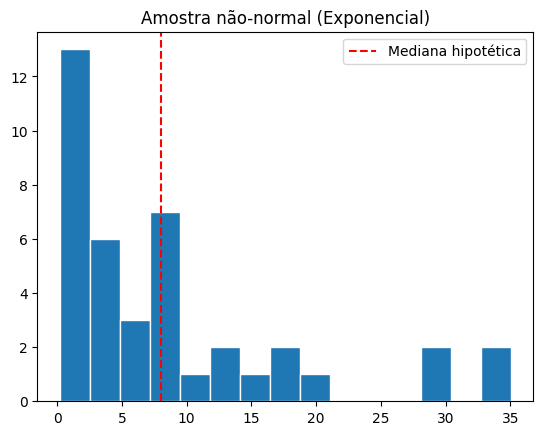

In [6]:
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

# Exemplo: amostra não-normal
np.random.seed(42)
amostra = np.random.exponential(scale=10, size=40)  # distribuição assimétrica
valor_hipotetico = 8

# Teste de Wilcoxon
res = wilcoxon(amostra - valor_hipotetico, alternative='two-sided')

print("Estatística W:", res.statistic)
print("p-valor:", res.pvalue)

# Visualização
plt.hist(amostra, bins=15, edgecolor='white')
plt.axvline(valor_hipotetico, color='red', linestyle='--', label='Mediana hipotética')
plt.title("Amostra não-normal (Exponencial)")
plt.legend()
plt.show()

### Pipeline para grande Outliers

In [7]:
import numpy as np
from scipy import stats
from typing import Dict, Tuple, Optional

# =========================================================
# Utilidades robustas
# =========================================================
def mad(x: np.ndarray, center: Optional[float] = None) -> float:
    """
    MAD (Median Absolute Deviation) não-reamostrado.
    """
    x = np.asarray(x)
    c = np.median(x) if center is None else center
    return np.median(np.abs(x - c))

def winsorize(x: np.ndarray, gamma: float = 0.2) -> np.ndarray:
    """
    Winsorização bilateral em proporção gamma (0 <= gamma < 0.5).
    Substitui a cauda inferior pelo quantil gamma e a superior por 1-gamma.
    """
    if not (0 <= gamma < 0.5):
        raise ValueError("gamma deve estar em [0, 0.5)")
    q_low, q_high = np.quantile(x, [gamma, 1 - gamma])
    w = x.copy()
    w[w < q_low] = q_low
    w[w > q_high] = q_high
    return w

def trimmed_mean_and_se(x: np.ndarray, gamma: float = 0.2) -> Tuple[float, float]:
    """
    Média aparada a 100*gamma% em cada cauda e erro padrão via variância winsorizada.
    Para 1-amostra, usamos:
        se(trimmed_mean) = sqrt( s_w^2 / (n * (1 - 2*gamma)^2) )
    onde s_w^2 é a variância amostral dos dados winsorizados.
    """
    x = np.asarray(x)
    n = x.size
    if n < 2:
        raise ValueError("A amostra precisa ter pelo menos 2 observações.")
    if not (0 <= gamma < 0.5):
        raise ValueError("gamma deve estar em [0, 0.5)")
    # Média aparada
    x_sorted = np.sort(x)
    g = int(np.floor(gamma * n))
    x_trim = x_sorted[g:n - g] if g > 0 else x_sorted
    tmean = x_trim.mean()

    # Variância winsorizada
    w = winsorize(x, gamma)
    sw2 = np.var(w, ddof=1)
    se = np.sqrt(sw2 / (n * (1 - 2 * gamma) ** 2))
    return tmean, se

# =========================================================
# Testes 1-amostra
# =========================================================
def t_test_one_sample(x: np.ndarray, mu0: float, alpha: float = 0.05) -> Dict:
    res = stats.ttest_1samp(x, popmean=mu0, alternative='two-sided')
    n = x.size
    mean = np.mean(x)
    sem = stats.sem(x)
    df = n - 1
    tcrit = stats.t.ppf(1 - alpha/2, df=df)
    ci = (mean - tcrit * sem, mean + tcrit * sem)
    return {
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        "df": int(df),
        "mean": float(mean),
        "ci": tuple(map(float, ci)),
        "note": "Sensível a outliers (use como referência)."
    }

def wilcoxon_one_sample(x: np.ndarray, mu0: float, alpha: float = 0.05) -> Dict:
    # Wilcoxon sobre as diferenças em relação a mu0
    dif = x - mu0
    # remove zeros exatos (empates na diferença)
    dif = dif[dif != 0]
    if dif.size == 0:
        return {"statistic": 0.0, "pvalue": 1.0, "median": float(mu0), "note": "Todos os pontos iguais a mu0."}
    res = stats.wilcoxon(dif, alternative='two-sided', zero_method='wilcox')
    # IC para a mediana (opcional, aproximado via Hodges-Lehmann)
    #hl = stats.hmedian(x)  # Hodges-Lehmann (SciPy >= 1.11); se indisponível, pode comentar
    return {
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        #"median_hl": float(hl),
        "note": "Teste não paramétrico para MEDIANA; robusto a outliers."
    }

def trimmed_mean_one_sample(x: np.ndarray, mu0: float, alpha: float = 0.05, gamma: float = 0.2) -> Dict:
    """
    Teste 1-amostra com média aparada (Yuen 1-amostra).
    t = (tmean - mu0) / se   com df ~ n-1
    """
    n = x.size
    tmean, se = trimmed_mean_and_se(x, gamma=gamma)
    df = n - 1
    tstat = (tmean - mu0) / se
    pval = 2 * (1 - stats.t.cdf(abs(tstat), df=df))
    tcrit = stats.t.ppf(1 - alpha/2, df=df)
    ci = (tmean - tcrit * se, tmean + tcrit * se)
    return {
        "gamma": float(gamma),
        "trimmed_mean": float(tmean),
        "statistic": float(tstat),
        "pvalue": float(pval),
        "df": int(df),
        "ci": tuple(map(float, ci)),
        "note": "MÉDIA aparada (robusta) + variância winsorizada; recomendado com outliers."
    }

def bootstrap_mean_test(
    x: np.ndarray,
    mu0: float,
    alpha: float = 0.05,
    n_boot: int = 20000,
    random_state: Optional[int] = 42
) -> Dict:
    """
    Bootstrap bilateral para H0: mu = mu0 com 'shift bootstrap':
      1) desloca a amostra para impor H0: x_shift = x - mean(x) + mu0
      2) reamostra com reposição de x_shift
      3) calcula a distribuição bootstrap da média
      4) p-valor = proporção de |mean* - mu0| >= |mean_obs - mu0|
    Também retorna IC percentil para a MÉDIA observada (sem o shift).
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    n = x.size
    mean_obs = x.mean()

    # Shift sob H0
    x_shift = x - mean_obs + mu0

    # Bootstrap sob H0 (para p-valor)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means_H0 = x_shift[idx].mean(axis=1)
    t_obs = abs(mean_obs - mu0)
    pval = np.mean(np.abs(boot_means_H0 - mu0) >= t_obs)

    # Bootstrap da média observada (IC percentil)
    idx2 = rng.integers(0, n, size=(n_boot, n))
    boot_means = x[idx2].mean(axis=1)
    ci_low, ci_high = np.quantile(boot_means, [alpha/2, 1 - alpha/2])

    return {
        "mean": float(mean_obs),
        "pvalue": float(pval),
        "ci_percentil": (float(ci_low), float(ci_high)),
        "note": "Bootstrap (robusto) para a MÉDIA; não assume normalidade e lida melhor com outliers."
    }

# =========================================================
# Função principal: roda tudo e resume
# =========================================================
def robust_one_sample_pipeline(
    x: np.ndarray,
    mu0: float,
    alpha: float = 0.05,
    trim_gamma: float = 0.2,
    n_boot: int = 20000,
    random_state: Optional[int] = 42
) -> Dict:
    x = np.asarray(x)
    summary = {
        "n": int(x.size),
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=1)),
        "median": float(np.median(x)),
        "mad": float(mad(x)),
        "mu0": float(mu0),
        "alpha": float(alpha),
    }

    out = {
        "summary": summary,
        "t_test": t_test_one_sample(x, mu0, alpha),
        "wilcoxon": wilcoxon_one_sample(x, mu0, alpha),
        "trimmed_mean": trimmed_mean_one_sample(x, mu0, alpha, gamma=trim_gamma),
        "bootstrap_mean": bootstrap_mean_test(x, mu0, alpha, n_boot=n_boot, random_state=random_state),
    }
    return out

# =========================================================
# Exemplo de uso
# =========================================================
if __name__ == "__main__":
    np.random.seed(123)

    # Cenário: grande amostra, distribuição ~normal, mas com outliers
    n = 5000
    mu_real = 0.5
    sigma = 1.0
    base = np.random.normal(loc=mu_real, scale=sigma, size=n)

    # Inserir outliers pesados em 2% dos pontos
    k = int(0.02 * n)
    idx = np.random.choice(n, size=k, replace=False)
    base[idx] += np.random.choice([10, -10], size=k)  # outliers simétricos grandes

    # Hipótese nula (média hipotética)
    mu0 = 0.0
    alpha = 0.05

    resultados = robust_one_sample_pipeline(
        base,
        mu0=mu0,
        alpha=alpha,
        trim_gamma=0.2,     # 20% de aparagem em cada cauda
        n_boot=20000,
        random_state=42
    )

    # Imprimir um resumo amigável
    import pprint
    pp = pprint.PrettyPrinter(indent=2, width=120, compact=False)
    print("==== RESUMO DOS TESTES (1 amostra, com outliers) ====")
    pp.pprint(resultados["summary"])
    print("\n[t‑teste clássico]         ", resultados["t_test"])
    print("\n[Wilcoxon (mediana)]       ", resultados["wilcoxon"])
    print("\n[Trimmed mean (Yuen 1-am.)]", resultados["trimmed_mean"])
    print("\n[Bootstrap (média)]        ", resultados["bootstrap_mean"])


==== RESUMO DOS TESTES (1 amostra, com outliers) ====
{ 'alpha': 0.05,
  'mad': 0.6849683515156646,
  'mean': 0.5170828868274326,
  'median': 0.5284915102187182,
  'mu0': 0.0,
  'n': 5000,
  'std': 1.7364383060711657}

[t‑teste clássico]          {'statistic': 21.056481789927105, 'pvalue': 2.2442114320781388e-94, 'df': 4999, 'mean': 0.5170828868274326, 'ci': (0.46894050079270866, 0.5652252728621566), 'note': 'Sensível a outliers (use como referência).'}

[Wilcoxon (mediana)]        {'statistic': 2998494.0, 'pvalue': 8.006559772163517e-223, 'note': 'Teste não paramétrico para MEDIANA; robusto a outliers.'}

[Trimmed mean (Yuen 1-am.)] {'gamma': 0.2, 'trimmed_mean': 0.5235429582545823, 'statistic': 34.16530707494299, 'pvalue': 0.0, 'df': 4999, 'ci': (0.4935015526176187, 0.5535843638915459), 'note': 'MÉDIA aparada (robusta) + variância winsorizada; recomendado com outliers.'}

[Bootstrap (média)]         {'mean': 0.5170828868274326, 'pvalue': 0.0, 'ci_percentil': (0.46934340017664694, 0.5

### Outro Pipeline robusto

In [8]:
import numpy as np
from typing import Optional, Dict, Tuple
from dataclasses import dataclass
from scipy import stats

# =========================================================
# Utilidades e diagnósticos
# =========================================================
def mad(x: np.ndarray, center: Optional[float] = None) -> float:
    """
    MAD (Median Absolute Deviation).
    """
    x = np.asarray(x)
    c = np.median(x) if center is None else center
    return float(np.median(np.abs(x - c)))

def detect_outliers_mad(x: np.ndarray, thresh: float = 3.5) -> Tuple[np.ndarray, float]:
    """
    Marca outliers pelo critério MAD: |x - mediana| / (1.4826*MAD) > thresh.
    Retorna (mask_outlier, taxa_outliers).
    """
    x = np.asarray(x)
    med = np.median(x)
    mad_val = mad(x, center=med)
    if mad_val == 0:
        # se MAD zero, use fallback por IQR
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        if iqr == 0:
            mask = np.zeros_like(x, dtype=bool)
        else:
            lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            mask = (x < lb) | (x > ub)
    else:
        modified_z = 0.6745 * (x - med) / (1.4826 * mad_val)
        mask = np.abs(modified_z) > thresh
    rate = float(mask.mean())
    return mask, rate

@dataclass
class NormalityResult:
    n: int
    test: str
    stat: float
    pvalue: float
    is_normal: bool

def normality_check(x: np.ndarray, alpha: float = 0.05) -> NormalityResult:
    """
    Verifica normalidade escolhendo um teste adequado ao tamanho da amostra:
    - n <= 5000: Shapiro-Wilk (bom poder)
    - n > 5000: D’Agostino-Pearson (normaltest)
    """
    x = np.asarray(x)
    n = x.size
    if n <= 5000:
        stat, p = stats.shapiro(x)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = stats.normaltest(x)
        test_name = "D’Agostino-Pearson"
    return NormalityResult(n=n, test=test_name, stat=float(stat), pvalue=float(p), is_normal=(p >= alpha))

# =========================================================
# Testes 1 amostra (param, não-param e robustos)
# =========================================================
def one_sample_ttest(x: np.ndarray, mu0: float, alpha: float = 0.05) -> Dict:
    res = stats.ttest_1samp(x, popmean=mu0, alternative="two-sided")
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = x.size - 1
    tcrit = float(stats.t.ppf(1 - alpha/2, df=df))
    ci = (mean - tcrit * sem, mean + tcrit * sem)
    return {
        "method": "t-test (1 amostra)",
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        "df": int(df),
        "estimate": {"mean": mean, "sem": sem},
        "ci": {"level": 1 - alpha, "low": float(ci[0]), "high": float(ci[1])}
    }

def one_sample_wilcoxon(x: np.ndarray, mu0: float, alpha: float = 0.05) -> Dict:
    dif = x - mu0
    dif = dif[dif != 0]  # remove empates exatos
    if dif.size == 0:
        return {"method": "Wilcoxon (1 amostra)", "statistic": 0.0, "pvalue": 1.0, "note": "Todas as diferenças são 0."}
    res = stats.wilcoxon(dif, alternative="two-sided", zero_method="wilcox")
    return {
        "method": "Wilcoxon (1 amostra)",
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        "estimate": {"median": float(np.median(x))}
    }

def winsorize(x: np.ndarray, gamma: float = 0.2) -> np.ndarray:
    if not (0 <= gamma < 0.5):
        raise ValueError("gamma deve estar em [0, 0.5)")
    q_low, q_high = np.quantile(x, [gamma, 1 - gamma])
    w = x.copy()
    w[w < q_low] = q_low
    w[w > q_high] = q_high
    return w

def trimmed_mean_and_se(x: np.ndarray, gamma: float = 0.2) -> Tuple[float, float]:
    """
    Média aparada a 100*gamma% em cada cauda e erro-padrão via variância winsorizada.
    se = sqrt( s_w^2 / (n * (1 - 2*gamma)^2) )
    """
    n = x.size
    x_sorted = np.sort(x)
    g = int(np.floor(gamma * n))
    x_trim = x_sorted[g:n-g] if g > 0 else x_sorted
    tmean = float(x_trim.mean())
    sw2 = float(np.var(winsorize(x, gamma), ddof=1))
    se = float(np.sqrt(sw2 / (n * (1 - 2 * gamma) ** 2)))
    return tmean, se

def one_sample_trimmed_mean_test(x: np.ndarray, mu0: float, alpha: float = 0.05, gamma: float = 0.2) -> Dict:
    n = x.size
    df = n - 1  # aproximação
    tmean, se = trimmed_mean_and_se(x, gamma)
    tstat = (tmean - mu0) / se
    pval = 2 * (1 - stats.t.cdf(abs(tstat), df=df))
    tcrit = float(stats.t.ppf(1 - alpha/2, df=df))
    ci = (tmean - tcrit * se, tmean + tcrit * se)
    return {
        "method": f"Yuen (média aparada {int(gamma*100)}% por cauda) — 1 amostra",
        "statistic": float(tstat),
        "pvalue": float(pval),
        "df": int(df),
        "estimate": {"trimmed_mean": float(tmean), "se": float(se)},
        "ci": {"level": 1 - alpha, "low": float(ci[0]), "high": float(ci[1])}
    }

def one_sample_bootstrap_mean(x: np.ndarray, mu0: float, alpha: float = 0.05, n_boot: int = 20000, random_state: Optional[int] = 42) -> Dict:
    """
    Bootstrap bilateral da média com 'shift sob H0':
      1) x_shift = x - mean(x) + mu0
      2) reamostrar x_shift com reposição e calcular média*
      3) p = P(|média* - mu0| >= |média_obs - mu0|)
    IC percentil da MÉDIA observada (sem shift).
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    n = x.size
    mean_obs = float(x.mean())

    # Shift sob H0
    x_shift = x - mean_obs + mu0
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means_H0 = x_shift[idx].mean(axis=1)
    pval = float(np.mean(np.abs(boot_means_H0 - mu0) >= abs(mean_obs - mu0)))

    # IC percentil da média observada
    idx2 = rng.integers(0, n, size=(n_boot, n))
    boot_means = x[idx2].mean(axis=1)
    ci_low, ci_high = np.quantile(boot_means, [alpha/2, 1 - alpha/2])

    return {
        "method": f"Bootstrap da média (n_boot={n_boot}) — 1 amostra",
        "pvalue": pval,
        "estimate": {"mean": mean_obs},
        "ci": {"level": 1 - alpha, "low": float(ci_low), "high": float(ci_high)}
    }

# =========================================================
# Testes 2 amostras (independente e pareado)
# =========================================================
def two_sample_t_or_welch(x: np.ndarray, y: np.ndarray, alpha: float = 0.05) -> Dict:
    # Verifica homogeneidade de variâncias
    lev_stat, lev_p = stats.levene(x, y, center="median")
    equal_var = lev_p >= alpha
    res = stats.ttest_ind(x, y, equal_var=equal_var, alternative="two-sided")
    method = "t-test (independente, equal_var=True)" if equal_var else "Welch t-test (variâncias desiguais)"
    return {
        "method": method,
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        "levene_p": float(lev_p),
        "estimate": {"mean_x": float(np.mean(x)), "mean_y": float(np.mean(y))}
    }

def two_sample_mannwhitney(x: np.ndarray, y: np.ndarray) -> Dict:
    res = stats.mannwhitneyu(x, y, alternative="two-sided")
    return {
        "method": "Mann-Whitney U (não paramétrico)",
        "statistic": float(res.statistic),
        "pvalue": float(res.pvalue),
        "estimate": {"median_x": float(np.median(x)), "median_y": float(np.median(y))}
    }

def paired_t_and_wilcoxon(x: np.ndarray, y: np.ndarray) -> Dict:
    # t pareado
    res_t = stats.ttest_rel(x, y, alternative="two-sided")
    # Wilcoxon pareado (sobre diferenças)
    dif = x - y
    dif = dif[dif != 0]
    if dif.size == 0:
        res_w = {"statistic": 0.0, "pvalue": 1.0}
    else:
        rw = stats.wilcoxon(dif, alternative="two-sided", zero_method="wilcox")
        res_w = {"statistic": float(rw.statistic), "pvalue": float(rw.pvalue)}
    return {
        "t_pareado": {"method": "t-test pareado", "statistic": float(res_t.statistic), "pvalue": float(res_t.pvalue)},
        "wilcoxon_pareado": {"method": "Wilcoxon pareado", **res_w}
    }

def two_sample_bootstrap_mean_diff(x: np.ndarray, y: np.ndarray, alpha: float = 0.05, n_boot: int = 20000, random_state: Optional[int] = 42) -> Dict:
    """
    Bootstrap bilateral para H0: mean(x) = mean(y) com 'shift sob H0':
      1) x_shift = x - mean(x) + m; y_shift = y - mean(y) + m, onde m é média combinada
      2) reamostrar x_shift e y_shift e avaliar |(mx* - my*) - 0|
    IC percentil para diferença de médias observada (sem shift).
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = x.size, y.size
    mean_x, mean_y = float(x.mean()), float(y.mean())
    obs_diff = mean_x - mean_y

    m = (mean_x*nx + mean_y*ny) / (nx + ny)
    x_shift = x - mean_x + m
    y_shift = y - mean_y + m

    idx_x = rng.integers(0, nx, size=(n_boot, nx))
    idx_y = rng.integers(0, ny, size=(n_boot, ny))
    boot_diff_H0 = x_shift[idx_x].mean(axis=1) - y_shift[idx_y].mean(axis=1)
    pval = float(np.mean(np.abs(boot_diff_H0) >= abs(obs_diff)))

    # IC percentil para diff observada
    idx_x2 = rng.integers(0, nx, size=(n_boot, nx))
    idx_y2 = rng.integers(0, ny, size=(n_boot, ny))
    boot_diff = x[idx_x2].mean(axis=1) - y[idx_y2].mean(axis=1)
    ci_low, ci_high = np.quantile(boot_diff, [alpha/2, 1 - alpha/2])

    return {
        "method": f"Bootstrap diferença de médias (n_boot={n_boot}) — 2 amostras",
        "pvalue": pval,
        "estimate": {"mean_x": mean_x, "mean_y": mean_y, "diff": obs_diff},
        "ci": {"level": 1 - alpha, "low": float(ci_low), "high": float(ci_high)}
    }

# =========================================================
# Lógica de decisão e Pipeline
# =========================================================
@dataclass
class Diagnostics:
    n: int
    normal_test: NormalityResult
    outlier_rate: float
    skew: float
    kurtosis_excess: float

def summarize_diagnostics(x: np.ndarray, alpha: float = 0.05) -> Diagnostics:
    x = np.asarray(x)
    n = x.size
    nor = normality_check(x, alpha=alpha)
    _, out_rate = detect_outliers_mad(x)
    skew = float(stats.skew(x, bias=False))
    kurt = float(stats.kurtosis(x, fisher=True, bias=False))  # excesso (0 = normal)
    return Diagnostics(n=n, normal_test=nor, outlier_rate=out_rate, skew=skew, kurtosis_excess=kurt)

def recommend_method_1sample(diag: Diagnostics, target: str = "mean") -> Dict:
    """
    target: 'mean' ou 'median'
    Heurística:
      - Outlier_rate > 5%  -> não paramétrico/robusto
      - n < 30 e !normal   -> não paramétrico
      - n grande e pouca distorção -> paramétrico OK
    """
    reasons = []
    if diag.outlier_rate > 0.05:
        reasons.append(f"muitos outliers (~{diag.outlier_rate:.1%})")
    if (diag.n < 30) and (not diag.normal_test.is_normal):
        reasons.append("n pequeno e não normal")
    if len(reasons) == 0 and diag.normal_test.is_normal:
        # cenário favorável
        if target == "mean":
            return {"recommendation": "parametric_ttest", "reason": "normalidade e poucos outliers"}
        else:
            return {"recommendation": "wilcoxon", "reason": "interesse em mediana"}
    # cenário robusto
    if target == "mean":
        return {"recommendation": "robust_mean", "reason": "; ".join(reasons) or "robustez desejada"}
    else:
        return {"recommendation": "wilcoxon", "reason": "; ".join(reasons) or "robustez desejada"}

def auto_hypothesis_test(
    x: np.ndarray,
    y: Optional[np.ndarray] = None,
    *,
    kind: str = "one-sample",          # 'one-sample' | 'two-sample-ind' | 'two-sample-paired'
    mu0: float = 0.0,                  # apenas para 1 amostra
    alpha: float = 0.05,
    target: str = "mean",              # 'mean' ou 'median' (prioridade interpretativa)
    trim_gamma: float = 0.2,
    n_boot: int = 20000,
    random_state: Optional[int] = 42
) -> Dict:
    """
    Pipeline automático:
      - Diagnóstico (normalidade, outliers, assimetria, curtose)
      - Escolha de método(s) e execução
      - Recomendação final + justificativa
    """
    out = {"settings": {
        "kind": kind, "alpha": alpha, "target": target,
        "trim_gamma": trim_gamma, "n_boot": n_boot
    }}

    if kind == "one-sample":
        diag = summarize_diagnostics(x, alpha=alpha)
        out["diagnostics"] = {
            "n": diag.n,
            "normal_test": {"test": diag.normal_test.test, "stat": diag.normal_test.stat, "pvalue": diag.normal_test.pvalue, "is_normal": diag.normal_test.is_normal},
            "outlier_rate": diag.outlier_rate,
            "skew": diag.skew,
            "kurtosis_excess": diag.kurtosis_excess
        }
        # Executa um conjunto de testes
        results = {
            "t_test": one_sample_ttest(x, mu0, alpha),
            "wilcoxon": one_sample_wilcoxon(x, mu0, alpha),
            "trimmed_mean": one_sample_trimmed_mean_test(x, mu0, alpha, gamma=trim_gamma),
            "bootstrap_mean": one_sample_bootstrap_mean(x, mu0, alpha, n_boot=n_boot, random_state=random_state),
        }
        out["results"] = results
        out["recommendation"] = recommend_method_1sample(diag, target=target)

    elif kind == "two-sample-ind":
        if y is None:
            raise ValueError("Para two-sample-ind, forneça y.")
        di_x = summarize_diagnostics(x, alpha=alpha)
        di_y = summarize_diagnostics(y, alpha=alpha)
        out["diagnostics"] = {
            "x": {"n": di_x.n, "normal": di_x.normal_test.is_normal, "outlier_rate": di_x.outlier_rate, "skew": di_x.skew, "kurtosis_excess": di_x.kurtosis_excess},
            "y": {"n": di_y.n, "normal": di_y.normal_test.is_normal, "outlier_rate": di_y.outlier_rate, "skew": di_y.skew, "kurtosis_excess": di_y.kurtosis_excess},
        }
        # Roda ambos os mundos + bootstrap robusto
        results = {
            "t_or_welch": two_sample_t_or_welch(x, y, alpha),
            "mann_whitney": two_sample_mannwhitney(x, y),
            "bootstrap_mean_diff": two_sample_bootstrap_mean_diff(x, y, alpha, n_boot=n_boot, random_state=random_state)
        }
        out["results"] = results

        # Regra simples de recomendação
        out_rate = max(di_x.outlier_rate, di_y.outlier_rate)
        if out_rate > 0.05 or (not di_x.normal_test.is_normal) or (not di_y.normal_test.is_normal):
            out["recommendation"] = {"recommendation": "nonparametric_or_bootstrap",
                                     "reason": f"não normalidade e/ou muitos outliers (até ~{out_rate:.1%})"}
        else:
            out["recommendation"] = {"recommendation": "parametric_t_or_welch", "reason": "normalidade e poucos outliers"}
    elif kind == "two-sample-paired":
        if y is None:
            raise ValueError("Para two-sample-paired, forneça y.")
        # Diagnóstico nas diferenças
        dif = x - y
        diag = summarize_diagnostics(dif, alpha=alpha)
        out["diagnostics"] = {
            "n_pares": diag.n,
            "normal_dif": diag.normal_test.is_normal,
            "outlier_rate_dif": diag.outlier_rate,
            "skew_dif": diag.skew,
            "kurtosis_excess_dif": diag.kurtosis_excess
        }
        results = paired_t_and_wilcoxon(x, y)
        out["results"] = results
        if (not diag.normal_test.is_normal) or diag.outlier_rate > 0.05:
            out["recommendation"] = {"recommendation": "wilcoxon_pareado", "reason": "diferenças não normais e/ou com outliers"}
        else:
            out["recommendation"] = {"recommendation": "t_pareado", "reason": "diferenças ~normais e poucos outliers"}
    else:
        raise ValueError("kind deve ser 'one-sample', 'two-sample-ind' ou 'two-sample-paired'.")

    return out

# =========================================================
# Exemplos de uso
# =========================================================
if __name__ == "__main__":
    np.random.seed(123)

    # ---------- 1) Uma amostra com outliers ----------
    n = 800
    x = np.random.normal(loc=0.3, scale=1.0, size=n)
    # injeta ~6% de outliers
    k = int(0.06 * n)
    idx = np.random.choice(n, size=k, replace=False)
    x[idx] += np.random.choice([8.0, -8.0], size=k)

    print("\n=== PIPELINE: 1 AMOSTRA (com outliers) ===")
    res1 = auto_hypothesis_test(x, kind="one-sample", mu0=0.0, target="mean", alpha=0.05, trim_gamma=0.2, n_boot=10000)
    from pprint import pprint
    pprint(res1["diagnostics"])
    pprint(res1["recommendation"])
    # Resultados dos testes (t, Wilcoxon, trimmed, bootstrap)
    # pprint(res1["results"])

    # ---------- 2) Duas amostras independentes ----------
    n1, n2 = 600, 700
    a = np.random.normal(0.0, 1.0, size=n1)
    b = np.random.normal(0.2, 1.2, size=n2)
    # injeta outliers em b
    kb = int(0.08 * n2)
    idb = np.random.choice(n2, size=kb, replace=False)
    b[idb] += np.random.choice([10, -10], size=kb)

    print("\n=== PIPELINE: 2 AMOSTRAS INDEPENDENTES (com outliers) ===")
    res2 = auto_hypothesis_test(a, y=b, kind="two-sample-ind", alpha=0.05, n_boot=10000)
    pprint(res2["diagnostics"])
    pprint(res2["recommendation"])
    # pprint(res2["results"])

    # ---------- 3) Duas amostras pareadas ----------
    n3 = 300
    before = np.random.normal(10, 2, size=n3)
    after = before - np.random.normal(0.4, 1.5, size=n3)  # efeito médio 0.4
    # outliers nas diferenças
    idp = np.random.choice(n3, size=int(0.07*n3), replace=False)
    after[idp] -= np.random.choice([6, -6], size=idp.size)

    print("\n=== PIPELINE: 2 AMOSTRAS PAREADAS (com outliers) ===")
    res3 = auto_hypothesis_test(before, y=after, kind="two-sample-paired", alpha=0.05)
    pprint(res3["diagnostics"])
    pprint(res3["recommendation"])
    # pprint(res3["results"])



=== PIPELINE: 1 AMOSTRA (com outliers) ===
{'kurtosis_excess': 8.346262347987842,
 'n': 800,
 'normal_test': {'is_normal': np.False_,
                 'pvalue': 1.7365243129791633e-32,
                 'stat': 0.760811604053033,
                 'test': 'Shapiro-Wilk'},
 'outlier_rate': 0.05875,
 'skew': -0.005487422197143842}
{'reason': 'muitos outliers (~5.9%)', 'recommendation': 'robust_mean'}

=== PIPELINE: 2 AMOSTRAS INDEPENDENTES (com outliers) ===
{'x': {'kurtosis_excess': -0.04318429605912355,
       'n': 600,
       'normal': np.True_,
       'outlier_rate': 0.0,
       'skew': -0.03334208303058783},
 'y': {'kurtosis_excess': 6.932815243943914,
       'n': 700,
       'normal': np.False_,
       'outlier_rate': 0.08,
       'skew': -0.5510619756537484}}
{'reason': 'não normalidade e/ou muitos outliers (até ~8.0%)',
 'recommendation': 'nonparametric_or_bootstrap'}

=== PIPELINE: 2 AMOSTRAS PAREADAS (com outliers) ===
{'kurtosis_excess_dif': 2.8623164121359572,
 'n_pares': 300,

### Busca Outliers

In [9]:
import numpy as np
from typing import Dict, Tuple

def mad(x: np.ndarray, center: float = None) -> float:
    x = np.asarray(x)
    c = np.median(x) if center is None else center
    return float(np.median(np.abs(x - c)))

def outlier_rate_iqr(x: np.ndarray, k: float = 1.5) -> Tuple[float, np.ndarray]:
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lb, ub = q1 - k * iqr, q3 + k * iqr
    mask = (x < lb) | (x > ub)
    return float(mask.mean()), mask

def outlier_rate_zscore(x: np.ndarray, c: float = 3.0) -> Tuple[float, np.ndarray]:
    mu = np.mean(x)
    sd = np.std(x, ddof=1)
    if sd == 0:
        mask = np.zeros_like(x, dtype=bool)
        return 0.0, mask
    z = (x - mu) / sd
    mask = np.abs(z) > c
    return float(mask.mean()), mask

def outlier_rate_modified_z(x: np.ndarray, c: float = 3.5) -> Tuple[float, np.ndarray]:
    med = np.median(x)
    mad_val = mad(x, center=med)
    if mad_val == 0:
        # fallback para IQR 1.5x quando MAD = 0
        return outlier_rate_iqr(x, k=1.5)
    z_rob = 0.6745 * (x - med) / (1.4826 * mad_val)
    mask = np.abs(z_rob) > c
    return float(mask.mean()), mask

def outlier_rate_percentile(x: np.ndarray, lower: float = 0.01, upper: float = 0.99) -> Tuple[float, np.ndarray]:
    lb, ub = np.quantile(x, [lower, upper])
    mask = (x < lb) | (x > ub)
    return float(mask.mean()), mask

def summarize_outliers(x: np.ndarray) -> Dict:
    x = np.asarray(x)
    rates = {}
    r_iqr15, m_iqr15 = outlier_rate_iqr(x, k=1.5)
    r_iqr3,  m_iqr3  = outlier_rate_iqr(x, k=3.0)
    r_z3,    m_z3    = outlier_rate_zscore(x, c=3.0)
    r_mz35,  m_mz35  = outlier_rate_modified_z(x, c=3.5)
    r_p1,    m_p1    = outlier_rate_percentile(x, lower=0.01, upper=0.99)

    return {
        "n": int(x.size),
        "metrics": {
            "IQR_1.5x": {"rate": r_iqr15, "count": int(m_iqr15.sum())},
            "IQR_3.0x": {"rate": r_iqr3,  "count": int(m_iqr3.sum())},
            "Z>|3|":    {"rate": r_z3,    "count": int(m_z3.sum())},
            "ModZ>|3.5| (MAD)": {"rate": r_mz35, "count": int(m_mz35.sum())},
            "Top/Bottom 1% (percentil)": {"rate": r_p1, "count": int(m_p1.sum())},
        },
        "masks": {
            "IQR_1.5x": m_iqr15,
            "IQR_3.0x": m_iqr3,
            "Z>|3|": m_z3,
            "ModZ>|3.5| (MAD)": m_mz35,
            "Top/Bottom 1% (percentil)": m_p1,
        }
    }

# Exemplo de uso
if __name__ == "__main__":
    np.random.seed(42)
    # Dados quase normais com outliers artificiais
    x = np.random.normal(loc=0, scale=1, size=1000)
    idx = np.random.choice(x.size, size=30, replace=False)
    x[idx] += np.random.choice([8, -8], size=idx.size)  # injeta outliers

    out = summarize_outliers(x)
    from pprint import pprint
    pprint(out["metrics"])

    # Acessar percentual (ex.: método robusto por MAD)
    perc_mad = out["metrics"]["ModZ>|3.5| (MAD)"]["rate"]
    print(f"Percentual (MAD): {perc_mad:.2%}")

{'IQR_1.5x': {'count': 34, 'rate': 0.034},
 'IQR_3.0x': {'count': 30, 'rate': 0.03},
 'ModZ>|3.5| (MAD)': {'count': 29, 'rate': 0.029},
 'Top/Bottom 1% (percentil)': {'count': 20, 'rate': 0.02},
 'Z>|3|': {'count': 29, 'rate': 0.029}}
Percentual (MAD): 2.90%


In [10]:
# Two-sample test

import pandas as pd
import numpy as np
from scipy import stats

# Exemplo: df com duas colunas numéricas 'serie1' e 'serie2'
# df = pd.read_csv('seu_arquivo.csv')  # se necessário
# Aqui só um exemplo fictício:
np.random.seed(42)
df = pd.DataFrame({
    'serie1': np.random.normal(20, 4, 30),
    'serie2': np.random.normal(22, 5, 28).tolist() + [np.nan, np.nan]  # tamanhos diferentes + NaN
})

# Remover NaNs de cada série separadamente (importante para independentes)
s1 = df['serie1'].dropna().values
s2 = df['serie2'].dropna().values

# (Opcional) Checar pressupostos
shapiro1 = stats.shapiro(s1)  # normalidade 1
shapiro2 = stats.shapiro(s2)  # normalidade 2
levene  = stats.levene(s1, s2, center='median')  # homogeneidade das variâncias

print(f"Shapiro serie1: W={shapiro1.statistic:.3f}, p={shapiro1.pvalue:.3f}")
print(f"Shapiro serie2: W={shapiro2.statistic:.3f}, p={shapiro2.pvalue:.3f}")
print(f"Levene: W={levene.statistic:.3f}, p={levene.pvalue:.3f}")

# Teste t (Welch recomendado)
t_welch = stats.ttest_ind(s1, s2, equal_var=False)
print(f"Welch t-test: t={t_welch.statistic:.3f}, p={t_welch.pvalue:.4f}")

# IC 95% para a diferença (s1 - s2) no esquema Welch
m1, m2 = s1.mean(), s2.mean()
v1, v2 = s1.var(ddof=1), s2.var(ddof=1)
n1, n2 = len(s1), len(s2)

diff = m1 - m2
se = np.sqrt(v1/n1 + v2/n2)
df_w = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
tcrit = stats.t.ppf(0.975, df_w)
ci_low, ci_high = diff - tcrit*se, diff + tcrit*se

print(f"Diferença de médias (serie1 - serie2) = {diff:.2f}")
print(f"IC95% (Welch): [{ci_low:.2f}, {ci_high:.2f}]  gl≈{df_w:.1f}")

# Tamanho de efeito (Cohen's d com pooled SD) + Hedges' g
s_pooled = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1 + n2 - 2))
cohens_d = (m1 - m2) / s_pooled
J = 1 - 3/(4*(n1+n2)-9)   # correção small-sample
hedges_g = cohens_d * J
print(f"Cohen's d = {cohens_d:.3f}  |  Hedges' g = {hedges_g:.3f}")

Shapiro serie1: W=0.975, p=0.687
Shapiro serie2: W=0.988, p=0.981
Levene: W=2.583, p=0.114
Welch t-test: t=-1.697, p=0.0958
Diferença de médias (serie1 - serie2) = -1.87
IC95% (Welch): [-4.08, 0.34]  gl≈50.7
Cohen's d = -0.450  |  Hedges' g = -0.444
